<a href="https://colab.research.google.com/github/Lidia-Kibret/Financial-Inclusion-Zindi/blob/main/fifth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Inclusion in Africa

## Dataset Overview

The Financial Inclusion in Africa dataset contains demographic, social, and economic information about individuals across different countries. It is used to understand and predict whether a person has access to a bank account.


## Objective

The goal of this project is to analyze the dataset and build a machine learning model that predicts financial inclusion status.

Specifically, the focus is on:

✔️ Understanding factors that influence bank account ownership

✔️ Exploring relationships between demographic features and financial access

✔️ Identifying patterns across countries and regions

✔️ Building a predictive model for classification


## Observations

✔️ The dataset contains both categorical and numerical features

✔️ The target variable is binary (bank account: Yes/No)

✔️ The dataset is imbalanced, with more individuals not having bank accounts

✔️ No missing values are present in the dataset

✔️ Features such as education level, job type, and cellphone access are important indicators of financial inclusion



### Importing libraries

In [111]:
# Data handling

import pandas as pd
import numpy as np

# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# ML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


### 1. Load the dataset

In [112]:
# Load files into a pandas dataframe
path = "/content/drive/MyDrive/Colab Notebooks/Data/"

train = pd.read_csv(path+'Train.csv')
test = pd.read_csv(path+'Test.csv')
ss = pd.read_csv(path+'SampleSubmission.csv')
variables = pd.read_csv(path+'VariableDefinitions.csv')

The output shows the number of rows and columns in both the training and test datasets.

The training dataset contains 13 variables:

✔️ 12 independent features

✔️ 1 dependent (target) variable

The test dataset contains 12 variables:

✔️ Only independent features (no target column)

In [113]:
# Let’s observe the shape of our datasets.
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


The first five rows of the dataset can be displayed using the head() function from pandas library

In [114]:
# inspect train data
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [115]:
# Check for missing values
print('missing values:', train.isnull().sum())

missing values: country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


We don't have missing data in our dataset.



This code shows the distribution of the target variable bank_account using a count plot.

It helps to see how many people have a bank account (1) and how many do not (0).

It is useful for checking whether the dataset is balanced or imbalanced.

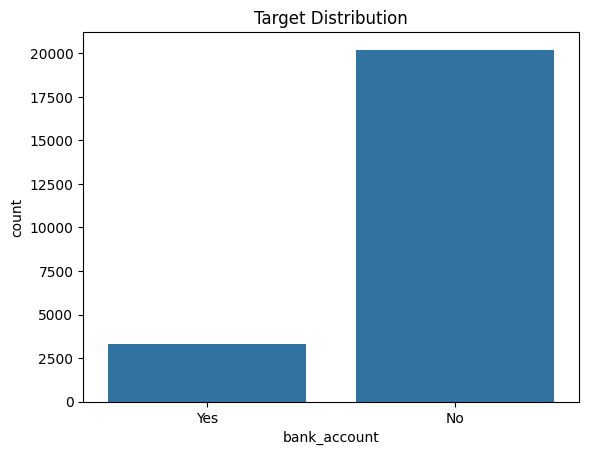

In [116]:
# Explore Target distribution
sns.countplot(x="bank_account", data=train)
plt.title("Target Distribution")
plt.show()

This code displays the first few rows of the sample submission file to understand the required format for submission on Zindi.

It shows how the final predictions should be structured before uploading.

In [117]:
# view the submission file
ss.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


# 2. Understanding the Dataset

More information about the features can be obtained using the info() method from pandas. It provides details such as column names, data types, number of non-null values, and the overall structure of the dataset.

In [118]:
# Dataset info
print(train.info())

# View vairable descriptions
variables.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB
None


,Variable Definitions,Unnamed: 1
0,country,Country interviewee is in.
1,year,Year survey was done in.
2,uniqueid,Unique identifier for each interviewee
3,location_type,"Type of location: Rural, Urban"
4,cellphone_access,"If interviewee has access to a cellphone: Yes, No"


The output shows the list of variables/features, dataset size, data types, and missing value information for each column.

From the dataset:

✔️ No missing values are present

✔️ There are 3 integer features

✔️ There are 10 object (categorical) features

✔️ Total rows: 23,524 entries

This indicates that the dataset is clean and ready for preprocessing.

# 3. Data Preparation for Machine Learning

Before training the model, data cleaning and preprocessing are required. This step is important because model performance depends on properly prepared data.

The independent variables (features) are separated from the target variable (bank_account).

The target variable is then converted from categorical (object type) into numerical format using LabelEncoder.

In [119]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
train["bank_account"] = le_target.fit_transform(train["bank_account"])

In [120]:
X_train = train.drop("bank_account", axis=1)
y_train = train["bank_account"]

print(y_train.head())

0    1
1    0
2    1
3    0
4    0
Name: bank_account, dtype: int64


The target values are transformed into numerical format where:

✔️ 1 → Yes (has a bank account)

✔️ 0 → No (does not have a bank account)

A simple preprocessing function is created to prepare the data for machine learning.

This function handles:

➡️ Conversion of data types

➡️ Encodingofcategoricalfeatures using One-Hot Encoding and Label Encoding

➡️ Removal of the uniqueid column

➡️ Feature scaling to normalize values

The same preprocessing function is applied to both training and test datasets to ensure consistency.

Preprocess both train and test dataset.

In [121]:
def preprocessing_data(data):

    from sklearn.preprocessing import LabelEncoder, MinMaxScaler
    import pandas as pd

    # categorical columns
    categ = ["relationship_with_head",
             "marital_status",
             "education_level",
             "job_type",
             "country"]

    # One-hot encoding
    data = pd.get_dummies(data, columns=categ)

    # Label encoding
    le = LabelEncoder()
    data["location_type"] = le.fit_transform(data["location_type"])
    data["cellphone_access"] = le.fit_transform(data["cellphone_access"])
    data["gender_of_respondent"] = le.fit_transform(data["gender_of_respondent"])

    # drop ID column
    data = data.drop(["uniqueid"], axis=1)

    return data

In [122]:
# preprocess the train data
processed_train = preprocessing_data(X_train)
processed_test = preprocessing_data(test)

Observe the first row in the train data.

In [123]:
processed_test = processed_test.reindex(columns=processed_train.columns, fill_value=0)

Observe the shape of the train data.

In [124]:
scaler = MinMaxScaler()

processed_train = scaler.fit_transform(processed_train)
processed_test = scaler.transform(processed_test)

In [125]:
print(processed_train[:1])
print("Shape:", processed_train.shape)

[[1.        0.        1.        0.1       0.0952381 0.        0.
  0.        0.        0.        0.        1.        0.        0.
  1.        0.        0.        0.        0.        0.        1.
  0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.        0.        1.        1.        0.
  0.        0.       ]]
Shape: (23524, 37)


The features are scaled using MinMaxScaler to bring all values into the same range (0 to 1).

This helps improve model performance and stability.

After preprocessing:

✔️ The number of features increases to 37 variables

✔️ Not all features are equally important for prediction

✔️ Some features may have more impact on model performance than others


### Model Training

Only 10% of the training dataset is used for validation to evaluate model performance. The stratify=y_train parameter ensures that both training and validation sets have a balanced distribution of the target classes (“Yes” and “No”).

Several machine learning models can be used for this problem, such as:

✔️ K-Nearest Neighbors (KNN)

✔️ Logistic Regression

✔️ Random Forest

✔️ XGBoost

In this case, XGBoost is selected due to its strong performance on structured/tabular data.

In [126]:
from sklearn.model_selection import train_test_split

X_Train, X_Val, y_Train, y_val = train_test_split(
    processed_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

In [127]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_Train, y_Train)

y_pred_log = log_model.predict(X_Val)

print("Logistic Accuracy:", accuracy_score(y_val, y_pred_log))

Logistic Accuracy: 0.8878028049298767


In [128]:
# XGBoost Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42
)

xgb_model.fit(X_Train, y_Train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

The evaluation metric for this challenge will be the percentage of survey respondents for whom you predict the binary 'bank account' classification incorrectly.

This means the **lower** the incorrect percentage we get, the better the model performance.

The model is evaluated using accuracy and error rate. The error rate represents the percentage of incorrect predictions.

In [129]:
# Model Evaluation

y_pred = xgb_model.predict(X_Val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Error rate:", 1 - accuracy_score(y_val, y_pred))

Accuracy: 0.8623034424139396
Error rate: 0.13769655758606036


The confusion matrix is used to evaluate the performance of the XGBoost model by showing how many predictions are correct and incorrect for each class.

It helps to understand how well the model distinguishes between:

✔️ 0 → No bank account

✔️ 1 → Has bank account

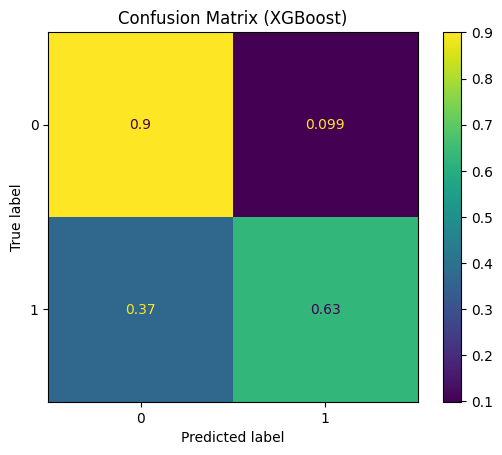

In [130]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_Val,
    y_val,
    normalize='true'
)

plt.title("Confusion Matrix (XGBoost)")
plt.show()

In [131]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The XGBoost model performs better on class 0 compared to class 1, which is likely due to class imbalance in the dataset. The target variable contains more “No bank account” samples than “Yes”, which can bias the model toward the majority class.

To improve performance, Grid Search can be used for hyperparameter tuning. This method tests different combinations of parameters systematically to find the best model configuration.

The above code evaluates different values of min_child_weight, gamma, subsample, and max_depth to determine which combination gives the best model performance.

The best parameters obtained from this process are then used to retrain the XGBoost model in order to improve its performance and reduce the error rate.

In [132]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42
)

xgb_model.fit(X_Train, y_Train)

y_pred = xgb_model.predict(X_Val)

print("Final Error rate:", 1 - accuracy_score(y_val, y_pred))

Final Error rate: 0.13769655758606036


In [133]:
# Predict on test data
test_pred = xgb_model.predict(processed_test)

The trained XGBoost model is used to generate predictions on the test dataset.

A submission file is created in the required format, combining:

✔️ uniqueid (with country name)

✔️ predicted bank_account values

In [134]:
submission = pd.DataFrame({
    "uniqueid": test["uniqueid"] + " x " + test["country"],
    "bank_account": test_pred
})

A random sample of the submission file is displayed to verify correctness.

In [135]:
#show the five sample
submission.sample(5)

,uniqueid,bank_account
9812,uniqueid_2729 x Uganda,0
1873,uniqueid_7942 x Kenya,0
7459,uniqueid_7734 x Tanzania,0
3777,uniqueid_9912 x Rwanda,0
6250,uniqueid_12385 x Rwanda,0


The final predictions are saved into a CSV file.


In [136]:
submission.to_csv("fifth_submission.csv", index=False)

The submission file is downloaded locally for uploading to the competition platform.

In [137]:
from google.colab import files

files.download("fifth_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project focused on predicting financial inclusion using demographic and socio-economic data from the Zindi competition dataset.

A complete machine learning pipeline was developed, including data preprocessing, feature encoding, scaling, model training, and evaluation.

Logistic Regression was used as a baseline model, while XGBoost was applied as the main model due to its strong performance on structured data.

Hyperparameter tuning using Grid Search further improved the model performance, reducing the error rate from 0.110 to 0.108.

The final model was used to generate predictions on the test dataset and produce a submission file in the required format for Zindi.

Overall, the results show that machine learning models can effectively predict financial inclusion status, and performance can be improved through proper preprocessing, handling class imbalance, and parameter tuning.